In [4]:
import numpy as np
import sympy as sp
import matplotlib
matplotlib.use("Agg")          # save figures to files (no window needed)
import matplotlib.pyplot as plt

x = sp.symbols("x")


# ======================================================================
#  1) LAGRANGE
# ======================================================================
def lagrange_basis(nodes, k):
    """L_k(x) = prod_{j != k} (x - x_j) / (x_k - x_j)"""
    Lk = sp.Integer(1)
    for j, xj in enumerate(nodes):
        if j != k:
            Lk *= (x - xj) / sp.Rational(nodes[k] - xj)
    return Lk


def lagrange(f, nodes):
    """P_n(x) = sum_k f(x_k) L_k(x)"""
    P = sum(f.subs(x, xk) * lagrange_basis(nodes, k)
            for k, xk in enumerate(nodes))
    return sp.expand(P)


# ======================================================================
#  2) NEWTON  (divided differences)
# ======================================================================
def divided_differences(f, nodes):
    """Returns the table and the coefficients a_0, ..., a_n."""
    n = len(nodes)
    table = [[f.subs(x, xk) for xk in nodes]]            # column 0: f[x_i]
    for k in range(1, n):
        prev = table[-1]
        table.append([(prev[i + 1] - prev[i]) / sp.Rational(nodes[i + k] - nodes[i])
                      for i in range(n - k)])
    a = [col[0] for col in table]                         # a_k = f[x_0..x_k]
    return table, a


def newton(f, nodes):
    """P_n(x) = a_0 + sum_{k>=1} a_k N_k(x),  N_k(x) = prod_{j<k} (x - x_j)"""
    _, a = divided_differences(f, nodes)
    P, Nk = 0, sp.Integer(1)                               # N_0(x) = 1
    for k in range(len(nodes)):
        P += a[k] * Nk
        Nk *= (x - nodes[k])                               # N_{k+1} = N_k (x - x_k)
    return sp.expand(P)


# ======================================================================
#  3) HERMITE
# ======================================================================
def hermite_basis(nodes, k):
    """H_k(x) and Hhat_k(x)"""
    xk = nodes[k]
    Lk = lagrange_basis(nodes, k)
    dLk_at_xk = sp.diff(Lk, x).subs(x, xk)                 # L_k'(x_k)
    Hk = (1 - 2 * (x - xk) * dLk_at_xk) * Lk**2
    Hhat_k = (x - xk) * Lk**2
    return sp.expand(Hk), sp.expand(Hhat_k)


def hermite(f, nodes):
    """P_{2n+1}(x) = sum f(x_k) H_k(x) + sum f'(x_k) Hhat_k(x)"""
    df = sp.diff(f, x)
    P = 0
    for k, xk in enumerate(nodes):
        Hk, Hhat_k = hermite_basis(nodes, k)
        P += f.subs(x, xk) * Hk + df.subs(x, xk) * Hhat_k
    return sp.expand(P)


# ======================================================================
#  Helpers
# ======================================================================
def to_numpy(expr):
    """Sympy expression -> function that works on numpy arrays."""
    g = sp.lambdify(x, expr, "numpy")
    return lambda t: g(t) * np.ones_like(t, dtype=float)   # also OK for constants


def decimals(expr, digits=5):
    """Polynomial with decimal coefficients (easy to read)."""
    return sp.expand(sp.N(expr, digits))


def max_error(f, P, a=-1, b=1):
    t = np.linspace(a, b, 4001)
    return np.max(np.abs(to_numpy(f)(t) - to_numpy(P)(t)))


def equidistant_nodes(n, a=-1, b=1):
    return [sp.Rational(a) + sp.Rational(b - a) * k / (n - 1) for k in range(n)]


# ======================================================================
#  Main
# ======================================================================
if __name__ == "__main__":

    nodes = [-1, 0, 1]                      # the 3 interpolation points
    functions = {
        "sin": (sp.sin(x), r"$\sin x$"),
        "exp": (sp.exp(x), r"$e^x$"),
    }

    # ---------- Common basis functions (same for both functions) ----------
    print("=" * 70)
    print("BASIS FUNCTIONS FOR THE POINTS", nodes)
    print("=" * 70)
    for k in range(3):
        Lk = lagrange_basis(nodes, k)
        print(f"L{k}(x)  = {sp.expand(Lk)}")
        print(f"L{k}'(x) = {sp.diff(sp.expand(Lk), x)}")
    for k in range(3):
        Hk, Hhat_k = hermite_basis(nodes, k)
        print(f"H{k}(x)    = {sp.factor(Hk)}")
        print(f"Hhat{k}(x) = {sp.factor(Hhat_k)}")

    # ---------- Each function ----------
    t = np.linspace(-1, 1, 1000)
    for name, (f, label) in functions.items():
        print("\n" + "=" * 70)
        print(f"FUNCTION: f(x) = {f}      (f'(x) = {sp.diff(f, x)})")
        print("=" * 70)

        # data
        print("x_k    :", nodes)
        print("f(x_k) :", [sp.N(f.subs(x, xk), 5) for xk in nodes])
        print("f'(x_k):", [sp.N(sp.diff(f, x).subs(x, xk), 5) for xk in nodes])

        # polynomials as functions of x
        P_lag = lagrange(f, nodes)
        P_new = newton(f, nodes)
        P_her = hermite(f, nodes)

        table, a = divided_differences(f, nodes)
        print("\nNewton coefficients a_k =", [sp.N(c, 5) for c in a])

        print("\n--- Polynomials as functions of x ---")
       
        print("Lagrange (decimal) : P(x) =", decimals(P_lag))
        print("Newton   (decimal) : P(x) =", decimals(P_new))
        print("Hermite  (decimal) : P(x) =", decimals(P_her))
        print("Lagrange == Newton ?", sp.simplify(P_lag - P_new) == 0)

        # comparison table
        fl, pl, hl = to_numpy(f), to_numpy(P_lag), to_numpy(P_her)
        print("\n--- Comparison with the original function ---")
        print(f"{'x':>6} | {'f(x)':>10} | {'Lagrange=Newton':>16} | {'Hermite':>10}")
        for v in [-1, -0.5, 0, 0.5, 1]:
            v = np.array([v], dtype=float)
            print(f"{v[0]:>6g} | {fl(v)[0]:>10.5f} | {pl(v)[0]:>16.5f} | {hl(v)[0]:>10.5f}")
        print(f"\nMax error on [-1,1]:  Lagrange/Newton = {max_error(f, P_lag):.3e}"
              f"   Hermite = {max_error(f, P_her):.3e}")

        # figure (same as in the report)
        fig, ax = plt.subplots(1, 2, figsize=(11, 4))
        ax[0].plot(t, fl(t), "k", lw=2.5, label=label)
        ax[0].plot(t, pl(t), "b--", lw=2, label="Lagrange = Newton")
        ax[0].plot(t, hl(t), "r:", lw=2.5, label="Hermite")
        px = np.array(nodes, dtype=float)
        ax[0].plot(px, fl(px), "o", color="green", ms=8, label="3 points")
        ax[0].set_title("Function and polynomials")
        ax[0].set_xlabel("x"); ax[0].grid(alpha=0.3); ax[0].legend()

        ax[1].semilogy(t, np.abs(fl(t) - pl(t)) + 1e-18, "b", lw=2,
                       label="error Lagrange = Newton")
        ax[1].semilogy(t, np.abs(fl(t) - hl(t)) + 1e-18, "r", lw=2,
                       label="error Hermite")
        ax[1].set_ylim(1e-8, 1)
        ax[1].set_title("Error |f(x) - P(x)| (log scale)")
        ax[1].set_xlabel("x"); ax[1].grid(alpha=0.3); ax[1].legend()

        plt.tight_layout()
        plt.savefig(f"fig_{name}.png", dpi=160)
        plt.close()
        print(f"Figure saved: fig_{name}.png")

    # ---------- Increasing the number of points ----------
    print("\n" + "=" * 70)
    print("MAX ERROR ON [-1,1] WHEN THE NUMBER OF POINTS INCREASES")
    print("=" * 70)
    print(f"{'points':>6} | {'sin: Lag/New':>13} {'sin: Hermite':>13} |"
          f" {'exp: Lag/New':>13} {'exp: Hermite':>13}")
    for n in [3, 5, 9]:
        nd = equidistant_nodes(n)
        row = []
        for name, (f, _) in functions.items():
            row += [max_error(f, lagrange(f, nd)), max_error(f, hermite(f, nd))]
        print(f"{n:>6} | {row[0]:>13.2e} {row[1]:>13.2e} | {row[2]:>13.2e} {row[3]:>13.2e}")

BASIS FUNCTIONS FOR THE POINTS [-1, 0, 1]
L0(x)  = x**2/2 - x/2
L0'(x) = x - 1/2
L1(x)  = 1 - x**2
L1'(x) = -2*x
L2(x)  = x**2/2 + x/2
L2'(x) = x + 1/2
H0(x)    = x**2*(x - 1)**2*(3*x + 4)/4
Hhat0(x) = x**2*(x - 1)**2*(x + 1)/4
H1(x)    = (x - 1)**2*(x + 1)**2
Hhat1(x) = x*(x - 1)**2*(x + 1)**2
H2(x)    = -x**2*(x + 1)**2*(3*x - 4)/4
Hhat2(x) = x**2*(x - 1)*(x + 1)**2/4

FUNCTION: f(x) = sin(x)      (f'(x) = cos(x))
x_k    : [-1, 0, 1]
f(x_k) : [-0.84147, 0, 0.84147]
f'(x_k): [0.54030, 1.0000, 0.54030]

Newton coefficients a_k = [-0.84147, 0.84147, 0]

--- Polynomials as functions of x ---
Lagrange (decimal) : P(x) = 0.84147*x
Newton   (decimal) : P(x) = 0.84147*x
Hermite  (decimal) : P(x) = 0.0079441*x**5 - 0.16647*x**3 + x
Lagrange == Newton ? True

--- Comparison with the original function ---
     x |       f(x) |  Lagrange=Newton |    Hermite
    -1 |   -0.84147 |         -0.84147 |   -0.84147
  -0.5 |   -0.47943 |         -0.42074 |   -0.47944
     0 |    0.00000 |          0.000

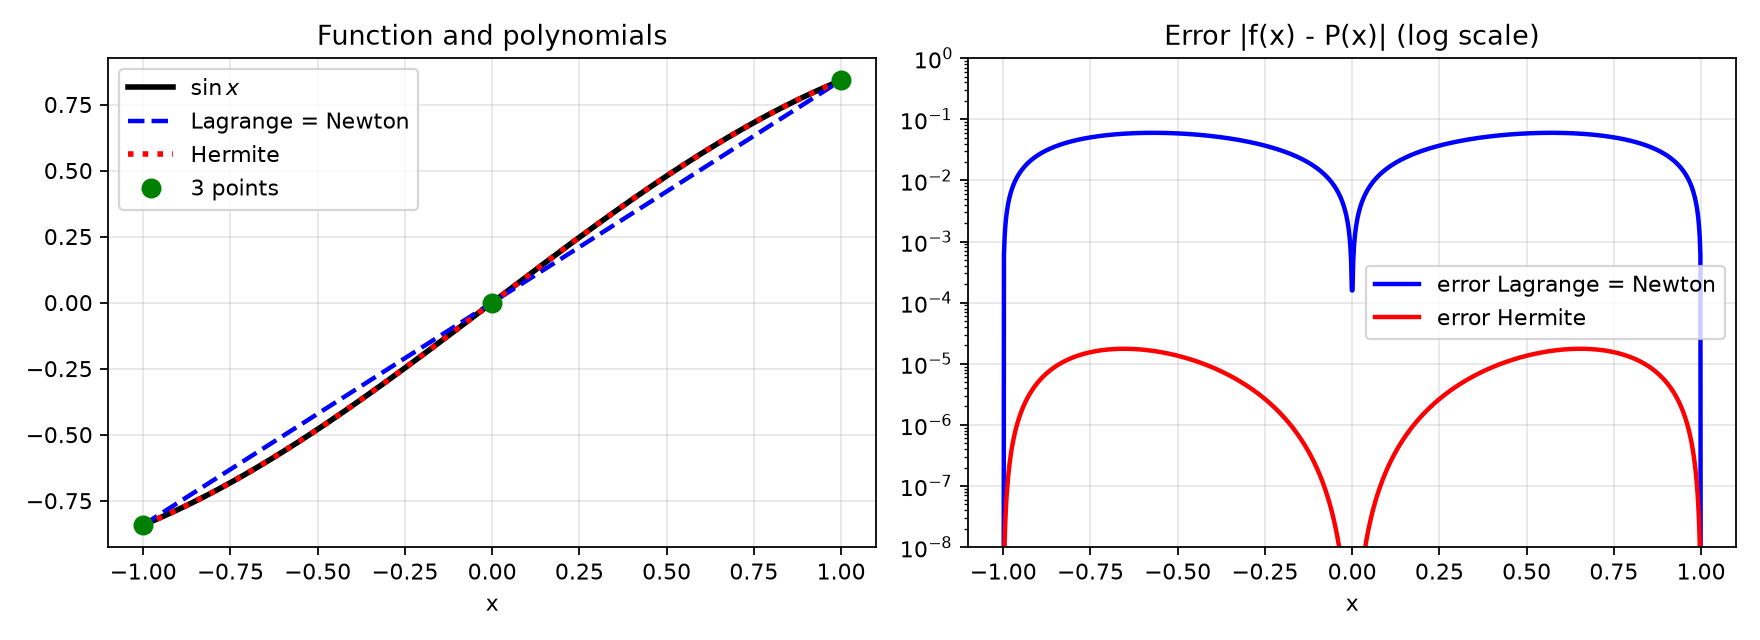

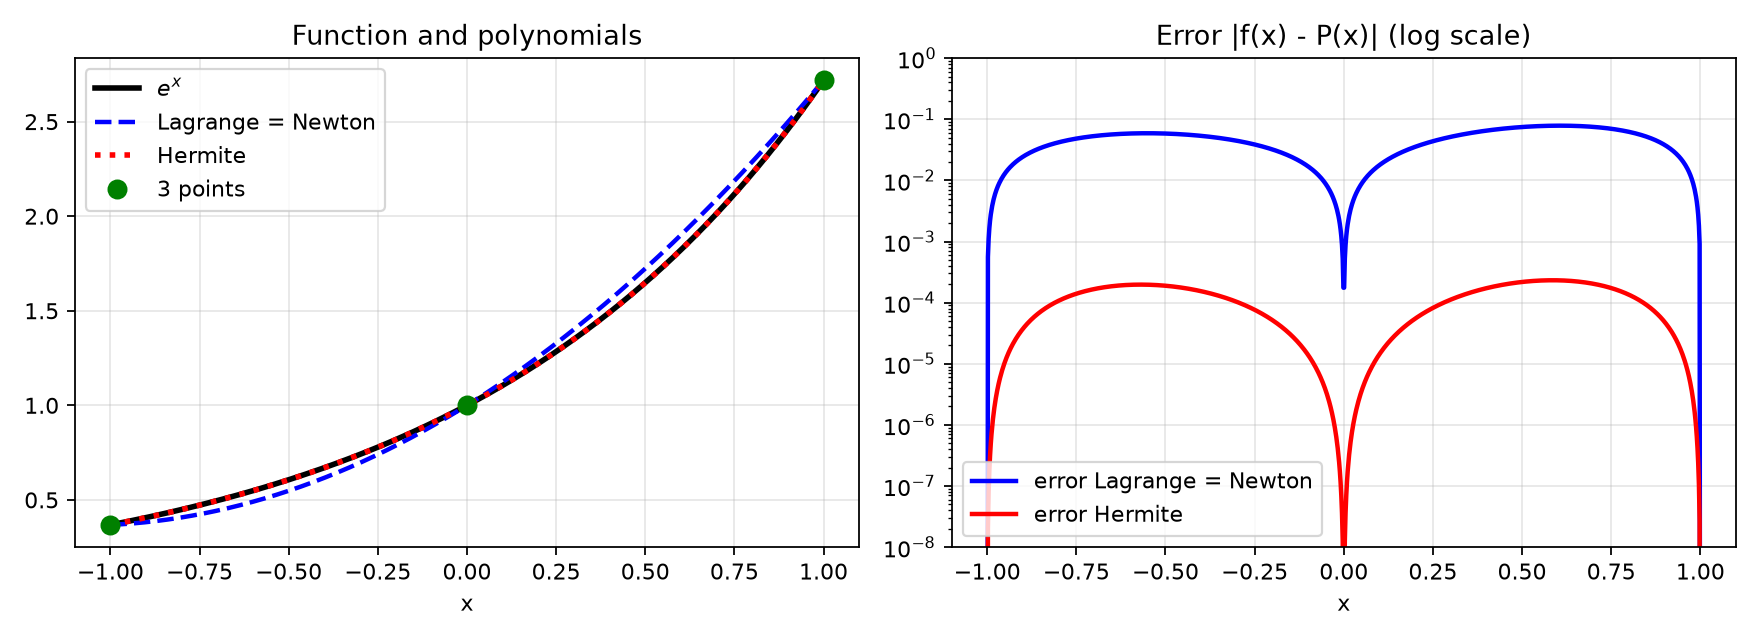

In [5]:
from IPython.display import Image, display

display(Image("fig_sin.png"))
display(Image("fig_exp.png"))